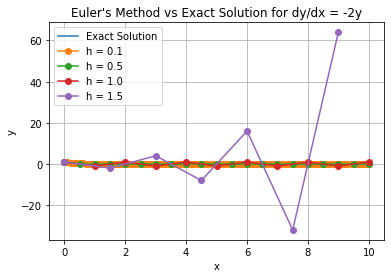


h = 0.1
Global error: [0.00000000e+00 1.87307531e-02 3.03200460e-02 3.68116361e-02
 3.97289641e-02 4.01994412e-02 3.90502119e-02 3.68817639e-02
 3.41243580e-02 3.10811602e-02 2.79611008e-02 2.49038124e-02
 2.19984766e-02 1.92979968e-02 1.68295975e-02 1.46026963e-02
 1.26147063e-02 1.08552718e-02 9.30932394e-03 7.95925305e-03
 6.78642384e-03 5.77220478e-03 4.89864227e-03 4.14887764e-03
 3.50738057e-03 2.96005381e-03 2.49424987e-03 2.09872930e-03
 1.76358241e-03 1.48012970e-03 1.24081214e-03 1.03907860e-03
 8.69275648e-04 7.26542737e-04 6.06714908e-04 5.06233773e-04
 4.22067255e-04 3.51637918e-04 2.92759559e-04 2.43581480e-04
 2.02539828e-04 1.68315330e-04 1.39796732e-04 1.16049320e-04
 9.62878964e-05 7.98536611e-05 6.61944875e-05 5.48481341e-05
 4.54279913e-05 3.76110033e-05 3.11274528e-05 2.57523371e-05
 2.12980978e-05 1.76085015e-05 1.45534969e-05 1.20248956e-05
 9.93275187e-06 8.20232949e-06 6.77156345e-06 5.58893849e-06
 4.61171681e-06 3.80445917e-06 3.13779156e-06 2.58737752e-06
 

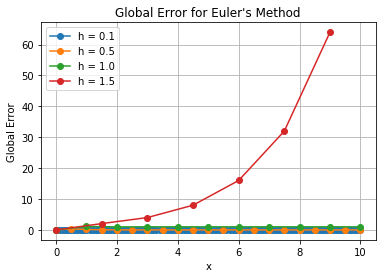


h = 0.1
Local error: [1.87307531e-02 1.53354436e-02 1.25555993e-02 1.02796552e-02
 8.41626988e-03 6.89065898e-03 5.64159441e-03 4.61894684e-03
 3.78167383e-03 3.09617266e-03 2.53493177e-03 2.07542660e-03
 1.69921558e-03 1.39120005e-03 1.13901827e-03 9.32549284e-04
 7.63506778e-04 6.25106479e-04 5.11793898e-04 4.19021404e-04
 3.43065709e-04 2.80878447e-04 2.29963822e-04 1.88278453e-04
 1.54149360e-04 1.26206821e-04 1.03329406e-04 8.45989624e-05
 6.92637722e-05 5.67083804e-05 4.64288950e-05 3.80127641e-05
 3.11222190e-05 2.54807178e-05 2.08618473e-05 1.70802359e-05
 1.39841144e-05 1.14492245e-05 9.37383223e-06 7.67464472e-06
 6.28346765e-06 5.14446820e-06 4.21193432e-06 3.44844016e-06
 2.82334401e-06 2.31155857e-06 1.89254409e-06 1.54948405e-06
 1.26861024e-06 1.03865022e-06 8.50374874e-07 6.96228061e-07
 5.70023325e-07 4.66695626e-07 3.82098061e-07 3.12835433e-07
 2.56127990e-07 2.09699862e-07 1.71687726e-07 1.40566021e-07
 1.15085724e-07 9.42242218e-08 7.71442681e-08 6.31603847e-08
 5

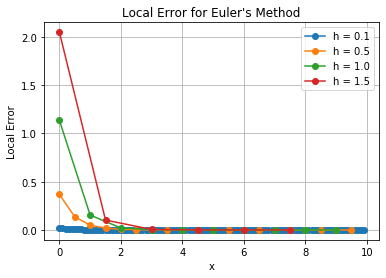

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
x_start, x_end = 0,10

# Function
def f(x, y):
    return -2 * y

# Exact solution
def exact_solution(x):
    return np.exp(-2*x)

h_values = [0.1, 0.5, 1.0, 1.5]

# Plot Euler solutions with exact solution
x_exact_plot = np.linspace(x_start, x_end, 1000)
plt.plot(x_exact_plot, exact_solution(x_exact_plot), label="Exact Solution")

for h in h_values:
    num_steps = int((x_end - x_start)/ h)
    x_values = x_start + (h * np.arange(num_steps + 1))
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1

    # Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + (h * f(x_values[i], y_values[i]))

    plt.plot(x_values, y_values, marker='o', label=f"h = {h}")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method vs Exact Solution for dy/dx = -2y")
plt.legend()
plt.grid(True)
plt.show()

# Plot global error
plt.figure()

for h in h_values:
    num_steps = int((x_end - x_start) / h)
    x_values = x_start + (h * np.arange(num_steps + 1))
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + (h * f(x_values[i], y_values[i]))

    y_exact = exact_solution(x_values)
    global_error = np.abs(y_values - y_exact)

    print("\nh =", h)
    print("Global error:", global_error)
    print("Max global error:", np.max(global_error))

    plt.plot(x_values, global_error, marker='o', label=f"h = {h}")

plt.xlabel('x')
plt.ylabel('Global Error')
plt.title("Global Error for Euler's Method")
plt.legend()
plt.grid(True)
plt.show()

# Plot local error
plt.figure()

for h in h_values:
    num_steps = int((x_end - x_start) / h)
    x_values = x_start + h* np.arange(num_steps + 1)

    local_error = np.zeros(num_steps)

    for i in range(num_steps):
        x_n = x_values[i]
        x_np1 = x_values[i + 1]

        y_exact_n = exact_solution(x_n)
        y_exact_np1 = exact_solution(x_np1)

        local_error[i] = abs(y_exact_np1 - (y_exact_n + h * f(x_n, y_exact_n)))

    print("\nh =", h)
    print("Local error:", local_error)
    print("Max local error:", np.max(local_error))

    plt.plot(x_values[:-1], local_error, marker='o', label=f"h = {h}")

plt.xlabel('x')
plt.ylabel('Local Error')
plt.title("Local Error for Euler's Method")
plt.legend()
plt.grid(True)
plt.show()